In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

In [3]:
df = pd.read_csv(r"D:\downloads\consumer_electronics_sales_data.csv")
df

,ProductID,ProductCategory,ProductBrand,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
0,5874,Smartphones,Other Brands,312.949668,18,0,2,1,0
1,5875,Smart Watches,Samsung,980.389404,35,1,7,2,1
2,5876,Tablets,Samsung,2606.718293,63,0,1,5,1
3,5877,Smartphones,Samsung,870.395450,63,1,10,3,1
4,5878,Tablets,Sony,1798.955875,57,0,17,3,0
...,...,...,...,...,...,...,...,...,...
8995,14869,Smart Watches,Samsung,1041.149163,36,1,16,4,0
8996,14870,Smartphones,Samsung,1485.694311,57,0,5,1,1
8997,14871,Headphones,Samsung,2887.369597,28,0,18,4,0
8998,14872,Tablets,HP,1490.453964,38,0,4,2,1


# Pre Prossecing Process (Before ML Model)

## 1- Encoding: At First my Predictors i will use dont need to encoding them they are Endoded roghtly Gender is Binary 0 and 1  while the other are numeric predictors (Customer satisf. and Customer Age)

# 2- Separate features (X) and (Y)

In [4]:
X = df[["CustomerGender", "CustomerAge", "CustomerSatisfaction"]]
Y = df["PurchaseIntent"]

# Train/Test Split (before ML model)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

# 2- Feature scaling: Done After Train/Test split to noramlize our features to Gaussian dist with mean 0 and std 1

In [6]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['CustomerAge', 'CustomerSatisfaction']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Models to select best of them to pass it to production:

# First: Linear (Based Model) supervised model (Logistic regression)

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# Precision and recall are close to each other within each class (0.84 vs 0.83, 0.87 vs 0.88), and close across both classes (0.83-0.88 range, no class collapsing to near-zero). If class imbalance were actually hurting this model, we will see one class with a much worse F1 than the other — e.g., class 0 at 0.83 vs class 1 at 0.50. That's not happening. Macro avg (0.85) and weighted avg (0.86) are also nearly identical, which further confirms the imbalance isn't distorting our metrics. So for Logistic Regression, accuracy alone would actually have been a fairly trustworthy number here.

In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
y_train_pred = model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8566666666666667
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       780
           1       0.87      0.88      0.87      1020

    accuracy                           0.86      1800
   macro avg       0.85      0.85      0.85      1800
weighted avg       0.86      0.86      0.86      1800

Train Accuracy: 0.8543055555555555
Test Accuracy: 0.8566666666666667


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       780
           1       0.87      0.88      0.87      1020

    accuracy                           0.86      1800
   macro avg       0.85      0.85      0.85      1800
weighted avg       0.86      0.86      0.86      1800

[[649 131]
 [127 893]]


# Instead: "The model achieves 94% test accuracy with a small train-test gap (95.6% vs 94%)(NO overfitting), indicating the result generalizes well and isn't inflated by overfitting. It substantially outperforms the Logistic Regression baseline (85.7%), suggesting the relationship between features and purchase intent has meaningful non-linear structure that Random Forest is capturing."

# Second: NON Linear (Based Model) Supervised classification model (Random Forest) using (Cross Entropy Loss)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# train
rf_model = RandomForestClassifier(random_state=42, criterion="entropy")
rf_model.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)
y_train_pred_rf = rf_model.predict(X_train)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
# feature importance
##importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
#print(importances)

Accuracy: 0.94
Train Accuracy: 0.9563888888888888
Test Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       780
           1       0.94      0.96      0.95      1020

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
weighted avg       0.94      0.94      0.94      1800

[[715  65]
 [ 43 977]]


# Third: NON Linear(Instant Based Model) Supervised model (KNN)

# Random Forest & XGBoost — trees split by asking threshold questions: "is Satisfaction ≥ 4?" That's exactly the kind of rule a tree naturally represents — a hard, axis-aligned cutoff. Given a rule this clean, both algorithms independently discover the same optimal split points, since there's really only one obviously correct place to cut.

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_train_pred_knn = knn_model.predict(X_train)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.94
Train Accuracy: 0.9563888888888888
Test Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       780
           1       0.94      0.96      0.95      1020

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
weighted avg       0.94      0.94      0.94      1800

[[715  65]
 [ 43 977]]


Accuracy: 0.94
Train Accuracy: 0.9563888888888888
Test Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       780
           1       0.94      0.96      0.95      1020

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
weighted avg       0.94      0.94      0.94      1800

[[715  65]
 [ 43 977]]
CustomerGender          0.781604
CustomerSatisfaction    0.152711
CustomerAge             0.065685
dtype: float32


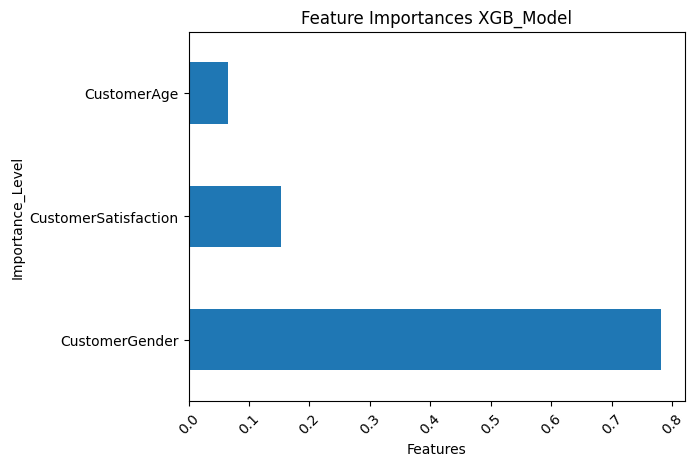

In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_train_pred_xgb = xgb_model.predict(X_train)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances_xgb)
importances_xgb.plot(kind='barh', title='Feature Importances XGB_Model', ylabel='Importance_Level', xlabel='Features')
plt.xticks(rotation=45)
plt.show()

## Discriminative VS Generative algorithm 

In [13]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.9366666666666666
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       780
           1       0.93      0.96      0.94      1020

    accuracy                           0.94      1800
   macro avg       0.94      0.93      0.94      1800
weighted avg       0.94      0.94      0.94      1800

[[711  69]
 [ 45 975]]


In [14]:
import numpy as np
print(np.array_equal(y_pred_knn, y_pred_xgb))

True


In [15]:
df.corr(numeric_only=True)['PurchaseIntent'].sort_values(ascending=False)

PurchaseIntent          1.000000
CustomerGender          0.504412
CustomerSatisfaction    0.391133
CustomerAge             0.289798
PurchaseFrequency      -0.001465
ProductID              -0.006596
ProductPrice           -0.017512
Name: PurchaseIntent, dtype: float64

In [16]:
print(type(knn_model))
print(type(xgb_model))
print(id(knn_model))
print(id(xgb_model))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>
2161586168096
2161586168432


In [17]:
df[['CustomerGender','CustomerSatisfaction','CustomerAge']].drop_duplicates().shape

(520, 3)

In [18]:
df.groupby(['CustomerGender','CustomerSatisfaction'])['PurchaseIntent'].agg(['mean','count'])

mean  count
CustomerGender CustomerSatisfaction                 
0              1                     0.054176    886
               2                     0.049550    888
               3                     0.041081    925
               4                     0.717647    850
               5                     0.733639    871
1              1                     0.715411    889
               2                     0.714903    926
               3                     0.712893    923
               4                     0.958861    948
               5                     0.955257    894

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, Y, cv=5, scoring='accuracy')
print("CV Scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV Scores: [1.         1.         1.         1.         0.76555556]
Mean: 0.953111111111111 Std: 0.09377777777777778


In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X, Y, cv=cv, scoring='accuracy')

print("CV Scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV Scores: [0.95888889 0.95611111 0.94666667 0.94388889 0.96      ]
Mean: 0.9531111111111112 Std: 0.0065790539302610935


In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_model, X, Y, cv=cv, scoring='accuracy')

print("CV Scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV Scores: [0.95888889 0.95611111 0.94666667 0.94388889 0.96      ]
Mean: 0.9531111111111112 Std: 0.0065790539302610935


In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True)
scores = cross_val_score(model, X, Y, cv=cv, scoring='accuracy')

print("CV Scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV Scores: [0.86333333 0.85833333 0.855      0.85333333 0.84611111]
Mean: 0.8552222222222223 Std: 0.00569383465569728


In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True)
scores = cross_val_score(svm_model, X, Y, cv=cv, scoring='accuracy')

print("CV Scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV Scores: [0.84944444 0.85611111 0.86055556 0.84944444 0.84333333]
Mean: 0.8517777777777779 Std: 0.005966987369821116


<Axes: xlabel='CustomerGender', ylabel='CustomerSatisfaction'>

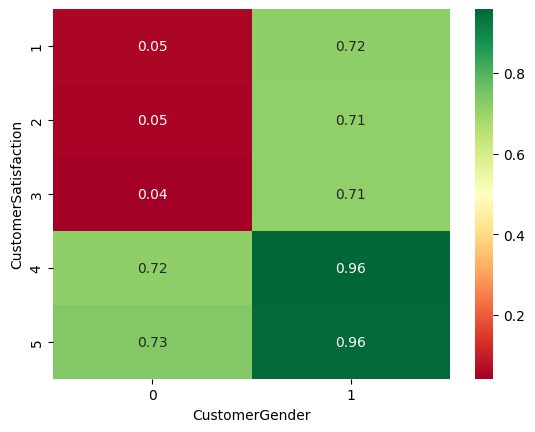

In [24]:
import seaborn as sns
pivot = df.pivot_table(index='CustomerSatisfaction', columns='CustomerGender', values='PurchaseIntent', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt='.2f')

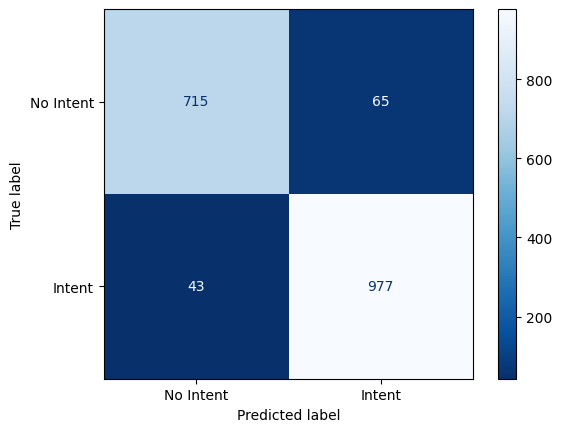

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Blues_r", display_labels=['No Intent','Intent'])

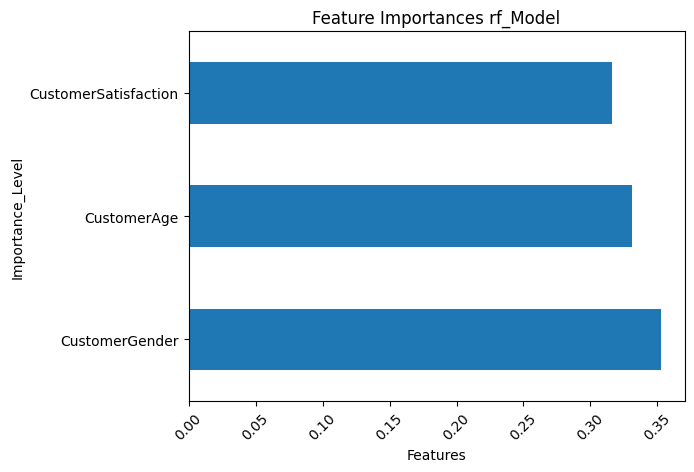

In [26]:
importances = pd.Series(rf_model.feature_importances_, index= X_train.columns).sort_values(ascending=False)
importances.plot(kind='barh', title='Feature Importances rf_Model', ylabel='Importance_Level', xlabel='Features')
plt.xticks(rotation=45)
plt.show()

In [27]:
# importances_log_reg = pd.Series(model.features_importances_, index=X_train.columns).sort_values(ascending=False)

# Here Supervised Part our data on Model just needed Cross validation Tunning run to its best performance but not needed Hyperparamter setup bec it gives its best perforamnce 

In [50]:
from sklearn.neural_network import MLPClassifier
mlp_model= MLPClassifier(hidden_layer_sizes=(64,32), random_state=42, activation='relu', max_iter=40)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))

Accuracy: 0.94

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       780
           1       0.94      0.96      0.95      1020

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
weighted avg       0.94      0.94      0.94      1800


Confusion Matrix:
 [[715  65]
 [ 43 977]]


c:\Users\oasm2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


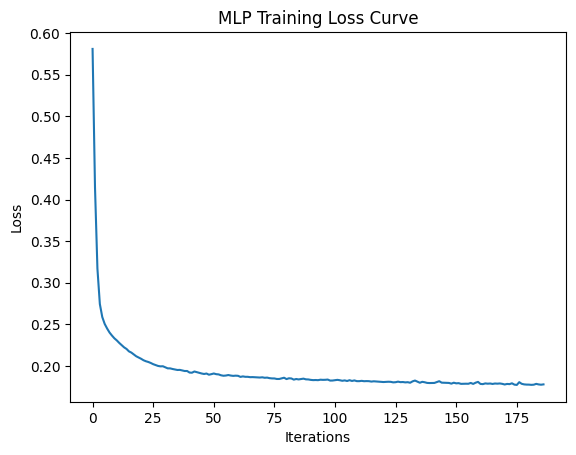

In [30]:
import matplotlib.pyplot as plt

plt.plot(mlp_model.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.show()

c:\Users\oasm2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\oasm2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\oasm2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\oasm2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization

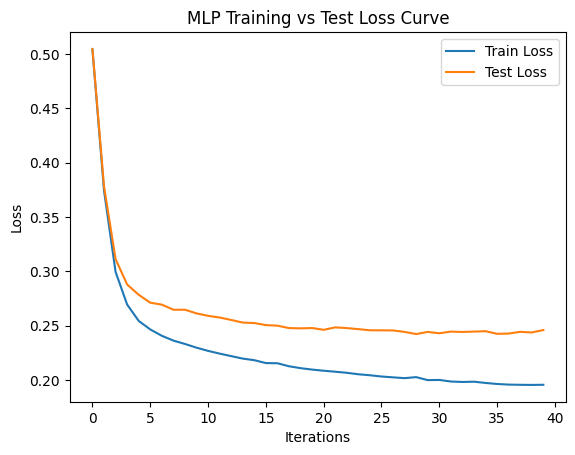

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt

n_iterations = 40
train_losses = []
test_losses = []

mlp_model = MLPClassifier(hidden_layer_sizes=(64,32), warm_start=True, max_iter=1)
classes = np.unique(y_train)

for i in range(n_iterations):
    mlp_model.fit(X_train, y_train)  # with warm_start=True, this continues training instead of restarting

    train_proba = mlp_model.predict_proba(X_train)
    test_proba = mlp_model.predict_proba(X_test)

    train_losses.append(log_loss(y_train, train_proba, labels=classes))
    test_losses.append(log_loss(y_test, test_proba, labels=classes))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training vs Test Loss Curve")
plt.legend()
plt.show()